In [ ]:
# Utility methods created to help make graphs easier
from image_utils import open_images, consruct_image, plot_image, plot_range_variance

In [5]:
# General packages used when working in jupyter notebook
import numpy as np
from matplotlib.image import imread
import matplotlib.pyplot as plt

In [2]:
images = open_images("./greyscale-images/")

In [ ]:
plot_image(consruct_image(images[0]))

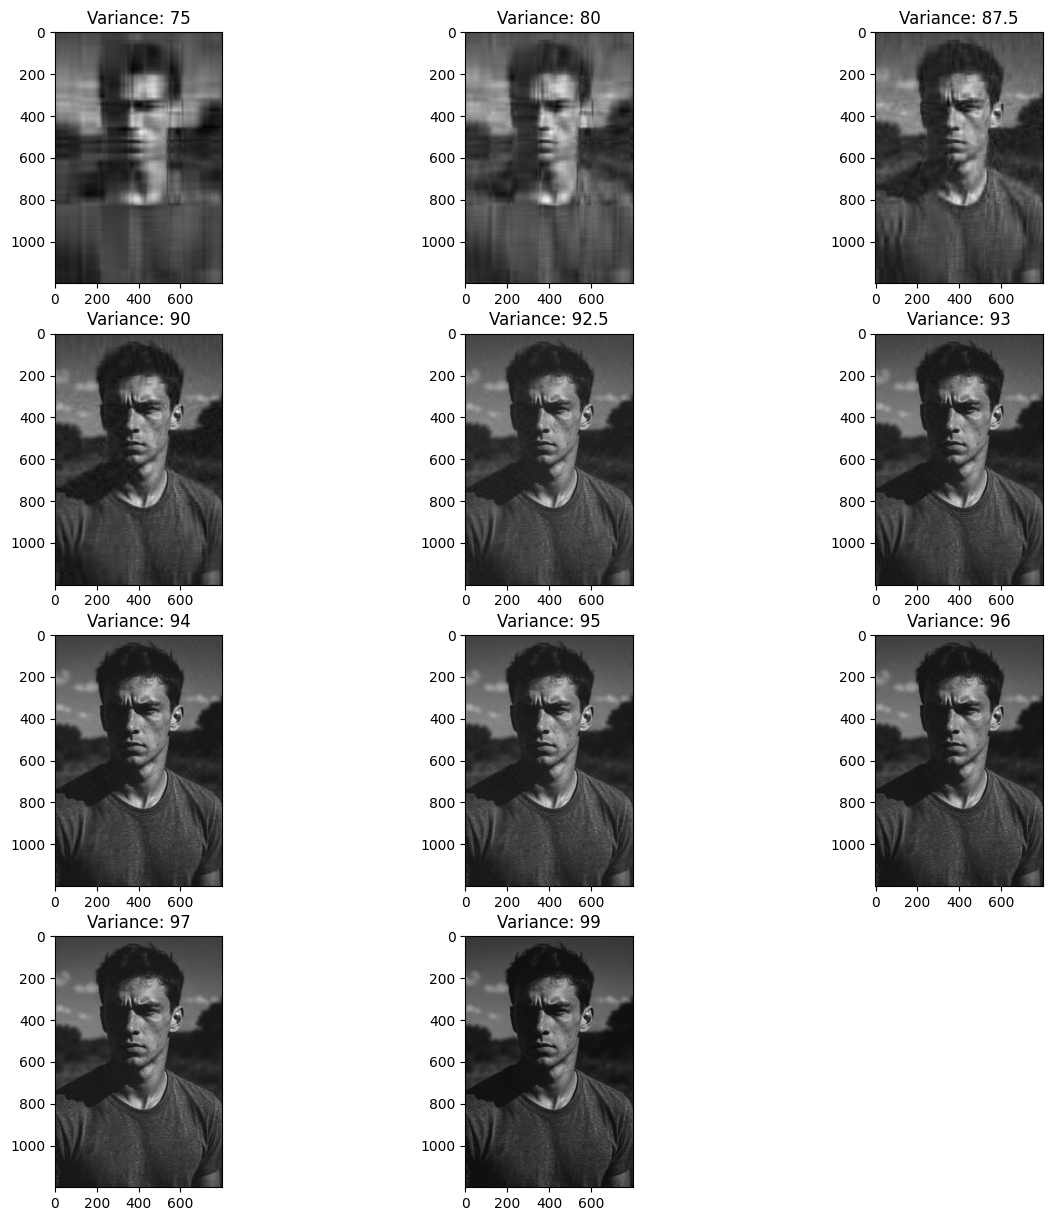

In [3]:
c_range = [75, 80, 87.5, 90, 92.5, 93, 94, 95, 96, 97, 99]

plot_range_variance(images[0], c_range)

In [ ]:
import numpy as np
from matplotlib.image import imread
import matplotlib.pyplot as plt

image_raw = imread("./greyscale-images/smiling-man-with-hat.webp");
print(image_raw.shape)

# Displaying the image
# plt.figure(figsize=[12,8])
# plt.imshow(image_raw)

In [ ]:
import os
image_dir = "./greyscale-images/"

images = []
for filename in os.listdir(image_dir):
    if filename.endswith((".png", ".jpg", ".jpeg", "webp")):
        path = os.path.join(image_dir, filename)
        img = plt.imread(path)
        images.append(img)

In [ ]:
image_sum = image_raw.sum(axis=2)
print(image_sum.shape)

image_bw = image_sum/image_sum.max()
print(image_bw.max())

# plt.figure(figsize=[12,8])
# plt.imshow(image_bw, cmap=plt.cm.gray)

In [ ]:
from sklearn.decomposition import PCA, IncrementalPCA
pca = PCA()
pca.fit(image_bw)

# Getting the cumulative variance

var_cumu = np.cumsum(pca.explained_variance_ratio_)*100

# How many PCs explain 95% of the variance?
k = np.argmax(var_cumu>95)
print("Number of components explaining 95% variance: "+ str(k))
#print("\n")

plt.figure(figsize=[10,5])
plt.title('Cumulative Explained Variance explained by the components')
plt.ylabel('Cumulative Explained variance')
plt.xlabel('Principal components')
plt.axvline(x=k, color="k", linestyle="--")
plt.axhline(y=95, color="r", linestyle="--")
ax = plt.plot(var_cumu)

In [ ]:
ipca = IncrementalPCA(n_components=k)
image_recon = ipca.inverse_transform(ipca.fit_transform(image_bw))

# Plotting the reconstructed image
plt.figure(figsize=[12,8])
plt.imshow(image_recon,cmap = plt.cm.gray)

In [ ]:
# Function to reconstruct and plot image for a given number of components

def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(image_bw))
    plt.imshow(image_recon,cmap = plt.cm.gray)
    

# k = 150
# plt.figure(figsize=[12,8])
# plot_at_k(60)

In [ ]:
ks = [10, 25, 50, 100, 150, 250]

plt.figure(figsize=[15,9])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]) + f" {image_recon.nbytes / 1024:.2f} KB")

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

In [ ]:
import os
image_dir = "./greyscale-images/"

images = []
for filename in os.listdir(image_dir):
    if filename.endswith((".png", ".jpg", ".jpeg", "webp")):
        path = os.path.join(image_dir, filename)
        img = plt.imread(path)
        images.append(img)



for image_i in images:
    image_sum = image_i.sum(axis=2)
    print(image_sum.shape)
    
    image_bw = image_sum/image_sum.max()
    print(image_bw.max())

    
    plt.figure(figsize=[15,15])
    for i in range(6):
        plt.subplot(2,3,i+1)
        plot_at_k(ks[i])
        plt.title("Components: "+str(ks[i]))
    
    plt.subplots_adjust(wspace=0.2, hspace=0.0)
    plt.show()

In [ ]:
image_i = images[4];


image_sum = image_i.sum(axis=2)
print(image_sum.shape)

image_bw = image_sum/image_sum.max()
print(image_bw.max())


plt.figure(figsize=[15,15])
for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

In [ ]:
import numpy as np

image_i = images[0]

image_sum = image_i.sum(axis=2)
print(image_sum.shape)

image_bw = image_sum/image_sum.max()
print(image_bw.max())

for k in [10, 25, 50, 100, 150, 250]:
    ipca = IncrementalPCA(n_components=k)
    compressed = ipca.fit_transform(image_bw)
    np.save(f"compressed_k{k}.npy", compressed)
    print(f"k={k}: {compressed.nbytes / 1024:.2f} KB")

NameError: name 'k_values' is not defined

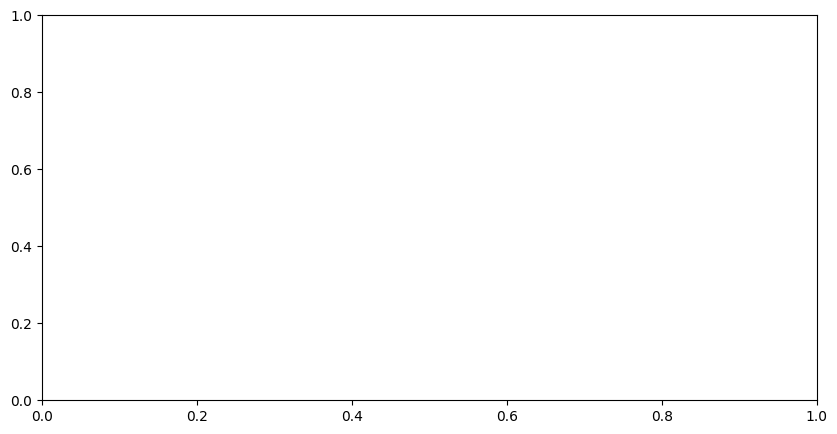

In [6]:
fig, ax1 = plt.subplots(figsize=[10, 5])

# size on left axis
ax1.plot(k_values, sizes, color="blue", label="Size (KB)")
ax1.set_xlabel("k (components)")
ax1.set_ylabel("Size (KB)", color="blue")

# variance on right axis
ax2 = ax1.twinx()    # second y axis sharing same x
ax2.plot(k_values, var_cumu[:250], color="red", label="Variance %")
ax2.set_ylabel("Cumulative Variance %", color="red")
ax2.axhline(y=95, color="red", linestyle="--")

plt.title("Size vs Variance Tradeoff")
plt.show()

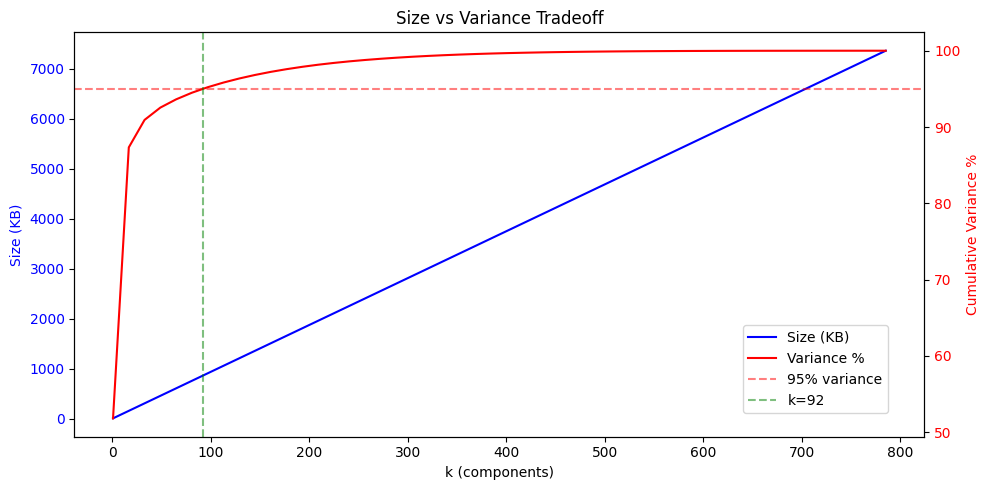

Image shape:       (1200, 800)
Max k:             800
Optimal k (95%%):  92
Size at optimal k: 7359.38 KB


In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import IncrementalPCA
import numpy as np
import math

def plot_size_variance(image_bw):
    # build k range from image dimensions
    max_k = min(image_bw.shape)
    k_values = range(1, max_k, max(1, max_k // 50))  # ~50 sample points
    
    sizes = []
    variances = []
    
    # fit full PCA once for variance
    from sklearn.decomposition import PCA
    pca = PCA()
    pca.fit(image_bw)
    var_cumu = np.cumsum(pca.explained_variance_ratio_) * 100
    
    for k in k_values:
        ipca = IncrementalPCA(n_components=k)
        compressed = ipca.fit_transform(image_bw)
        sizes.append(compressed.nbytes / 1024)
        variances.append(var_cumu[k])
    
    # find 95% variance k
    k_optimal = np.argmax(var_cumu > 95)
    
    # plot
    fig, ax1 = plt.subplots(figsize=[10, 5])
    
    ax1.plot(k_values, sizes, color="blue", label="Size (KB)")
    ax1.set_xlabel("k (components)")
    ax1.set_ylabel("Size (KB)", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    ax2 = ax1.twinx()
    ax2.plot(k_values, variances, color="red", label="Variance %")
    ax2.set_ylabel("Cumulative Variance %", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    ax2.axhline(y=95, color="red", linestyle="--", alpha=0.5, label="95% variance")
    ax2.axvline(x=k_optimal, color="green", linestyle="--", alpha=0.5, label=f"k={k_optimal}")
    
    plt.title("Size vs Variance Tradeoff")
    fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.15))
    plt.tight_layout()
    plt.show()
    
    print(f"Image shape:       {image_bw.shape}")
    print(f"Max k:             {max_k}")
    print(f"Optimal k (95%%):  {k_optimal}")
    print(f"Size at optimal k: {sizes[k_values.index(k_optimal) if k_optimal in k_values else -1]:.2f} KB")

# run it

plot_size_variance(images[0])